# **Desarrollo de una aplicación de Procesamiento del Lenguaje Natural.** 
# **Francisco Valera García.**

Esto es un codigo de prueba, tiene muchos errores de concepto como utilizar modelos con idiomas equivocados

In [1]:
import glob
import json
import re
from tqdm import tqdm
import gensim.downloader as api
import matplotlib.pyplot as plt
import nltk
import numpy as np
import praw
import seaborn as sns
import torch
from gensim.downloader import load
from gensim.models import KeyedVectors
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sentence_transformers import SentenceTransformer
from spellchecker import SpellChecker
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline, AutoModelForSeq2SeqLM

nltk.download("popular")
nltk.download('punkt_tab')
nltk.download('wordnet')

glove = api.load("glove-wiki-gigaword-100")

c:\Users\pablo\miniconda3\envs\reddit\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     C:\Users\pablo\AppData\Roaming\nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     C:\Users\pablo\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     C:\Users\pablo\AppData\Roaming\nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     C:\Users\pablo\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gutenberg is al

# 1. Compilación del corpus y uso de procesamiento léxico

En este bloque de código se lleva a cabo la extracción, estructuración y limpieza léxica del corpus textual a partir de la API de Reddit, utilizando la librería `praw`, la cual facilita el acceso a subreddits y la recopilación de publicaciones y comentarios. Inicialmente, se establece una conexión con la API autenticando mediante las credenciales de cliente, clave secreta y un user-agent. Se define una lista de subreddits temáticos (`nba`, `AITAH`, `nasa`, `cars`, `politics`, `science`) de los cuales se van a recuperar un máximo de 20 hilos principales cada uno, y hasta 50 comentarios por hilo. Por cada hilo, se almacenan metadatos relevantes (flair, título, autor, fecha de publicación, puntuación y contenido del post) y una lista de comentarios, cada uno con su autor, contenido textual, puntuación y fecha. Se excluye el contenido NSFW mediante una condición explícita, y se aplica la función `replace_more(limit=0)` para eliminar los comentarios anidados que podrían dificultar la estructura del JSON final. Posteriormente, se guarda la información recolectada en archivos `.json` individuales por subreddit, asegurando una estructura organizada y legible para su posterior análisis. En una segunda parte del código, se lleva a cabo el preprocesamiento léxico del texto para mejorar la calidad lingüística del corpus. Se descarga el conjunto de stopwords en inglés usando `nltk` y se inicializa un corrector ortográfico (`SpellChecker`) también para inglés. A través de la función `clean_text`, se eliminan URLs, menciones y caracteres no alfabéticos usando expresiones regulares, se corrigen palabras mal escritas y se filtran stopwords. Esta limpieza se aplica tanto al texto principal de los hilos como a los comentarios, sobrescribiendo los archivos `.json` actualizados. En conjunto, este proceso garantiza la compilación de un corpus textual amplio, limpio y representativo, preparado para las siguientes etapas de análisis lingüístico y modelado.


In [2]:
reddit = praw.Reddit(
    client_id="U1cbjxQXMCcRU1Bvet60RA",
    client_secret="YKDhzchaWbAvglen1qPBCITEykvHNQ",
    user_agent="PLN"
)

SUBREDDITS = ["nba", "AITAH", "nasa", "cars", "politics", "science"]
MAX_THREADS_PER_SUBREDDIT = 20
COMMENTS_PER_THREAD = 50

def scrape_reddit():
    for subreddit_name in SUBREDDITS:
        subreddit = reddit.subreddit(subreddit_name)
        threads_data = []
        
        
        for thread in tqdm(subreddit.top(limit=MAX_THREADS_PER_SUBREDDIT), desc=f"Extrayendo de r/{subreddit_name}"):
            if thread.over_18:  # Saltar contenido NSFW
                continue
                
            comments = []
            thread.comments.replace_more(limit=0)  # Limitar comentarios anidados
            for comment in thread.comments[:COMMENTS_PER_THREAD]:
                comments.append({
                    "user": str(comment.author),
                    "comment": comment.body,
                    "score": comment.score,
                    "date": comment.created_utc
                })
            
            threads_data.append({
                "flair": thread.link_flair_text,
                "title": thread.title,
                "author": str(thread.author),
                "date": thread.created_utc,
                "score": thread.score,
                "description": thread.selftext,
                "comments": comments
            })
        
        # Guardar en JSON
        with open(f"subreddit_{subreddit_name}.json", "w", encoding="utf-8") as f:
            json.dump(threads_data, f, indent=4, ensure_ascii=False)

scrape_reddit()

print("\n")

nltk.download('stopwords')
spell = SpellChecker(language='en')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r"http\S+|@\w+|[^a-zA-ZáéíóúñÁÉÍÓÚÑ ]", "", text)
    words = text.split()
    corrected = [spell.correction(word) if spell.correction(word) is not None else word for word in words]
    cleaned = [word for word in corrected if word.lower() not in stop_words]
    return " ".join(cleaned)

# Procesar todos los archivos JSON de subreddits
for subreddit in SUBREDDITS:
    filename = f"subreddit_{subreddit}.json"
    
    try:
        with open(filename, "r", encoding="utf-8") as f:
            threads_data = json.load(f)

        # Aplicar limpieza
        for thread in threads_data:
            thread["description"] = clean_text(thread["description"])
            for comment in thread["comments"]:
                comment["comment"] = clean_text(comment["comment"])

        
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(threads_data, f, indent=4, ensure_ascii=False)
            
        print(f"Procesado: {filename}")
        
    except FileNotFoundError:
        print(f"Archivo no encontrado: {filename}")
    except json.JSONDecodeError:
        print(f"Error decodificando: {filename}")

Extrayendo de r/nba: 20it [01:14,  3.75s/it]
Extrayendo de r/AITAH: 20it [01:14,  3.73s/it]
Extrayendo de r/nasa: 20it [00:34,  1.72s/it]
Extrayendo de r/cars: 20it [01:05,  3.28s/it]
Extrayendo de r/politics: 20it [01:19,  3.97s/it]
Extrayendo de r/science: 20it [01:11,  3.59s/it]
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pablo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!




Procesado: subreddit_nba.json
Procesado: subreddit_AITAH.json
Procesado: subreddit_nasa.json
Procesado: subreddit_cars.json
Procesado: subreddit_politics.json
Procesado: subreddit_science.json


# 2. Clasificador de Comentarios en Subreddits  

Este bloque desarrolla un sistema de clasificación automática de comentarios para predecir a qué subreddit pertenece cada uno. En la primera parte, se realiza la carga de datos preprocesados desde archivos `.json` previamente generados, donde se recogen los comentarios y se les asocia su respectiva etiqueta (el nombre del subreddit), así como un identificador derivado del título del hilo. Posteriormente, se procede a dividir el conjunto de datos en entrenamiento y validación, utilizando un criterio robusto basado en los identificadores de hilo para evitar sesgos que surgirían si se mezclan comentarios del mismo hilo entre ambos conjuntos. En la siguiente sección se implementan distintos modelos de clasificación. Primero, se emplean representaciones tradicionales de texto como BoW (Bag of Words) y TF-IDF utilizando `CountVectorizer` y `TfidfVectorizer` con bigramas, seguidos por un clasificador Random Forest; se entrenan sobre los vectores del conjunto de entrenamiento y se evalúan mediante métricas de `classification_report` y matrices de confusión que se visualizan con `seaborn`. A continuación, se utiliza un enfoque semántico más avanzado: se representan los comentarios con embeddings promedio de GloVe, previamente descargados usando `gensim.downloader`, y se entrena un clasificador SVM. Finalmente, se aborda el uso de modelos Transformers mediante `bert-base-uncased` de HuggingFace, adaptado a una tarea de clasificación multiclase con Fine-Tuning. Para ello, se define una clase `Dataset` personalizada para tokenizar los comentarios y mapear las etiquetas textuales a índices numéricos. El entrenamiento del modelo se realiza con la API `Trainer` de `transformers`, especificando parámetros como el número de épocas y el tamaño de lote. Al finalizar, se evalúa el modelo con predicciones sobre el conjunto de validación y se visualiza el rendimiento con métricas y una matriz de confusión. En conjunto, este enfoque permite comparar la efectividad de tres paradigmas distintos (representaciones tradicionales, embeddings y transformers) en la tarea de clasificación de texto, proporcionando una base sólida para evaluar qué modelo resulta más eficaz para discriminar entre comunidades temáticas de Reddit.



══════════════════════════════════════════════════
 Modelos Tradicionales 
══════════════════════════════════════════════════

BoW + Random Forest:
              precision    recall  f1-score   support

       AITAH       0.86      0.57      0.68       488
        cars       0.55      0.56      0.56       350
        nasa       0.35      0.74      0.47       242
         nba       0.12      0.53      0.20        97
    politics       0.80      0.37      0.51       500
     science       0.74      0.43      0.55       376

    accuracy                           0.51      2053
   macro avg       0.57      0.53      0.50      2053
weighted avg       0.67      0.51      0.55      2053



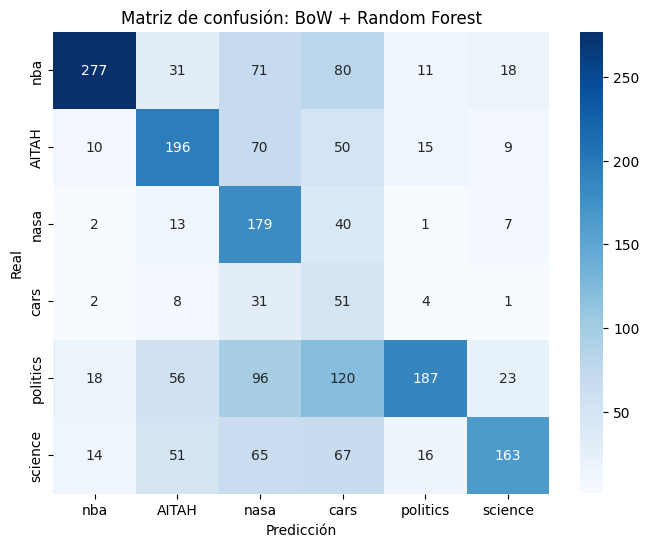

3

TF-IDF + Random Forest:
              precision    recall  f1-score   support

       AITAH       0.83      0.59      0.69       488
        cars       0.60      0.55      0.57       350
        nasa       0.32      0.75      0.45       242
         nba       0.12      0.45      0.19        97
    politics       0.79      0.38      0.51       500
     science       0.74      0.43      0.54       376

    accuracy                           0.51      2053
   macro avg       0.57      0.53      0.49      2053
weighted avg       0.67      0.51      0.55      2053



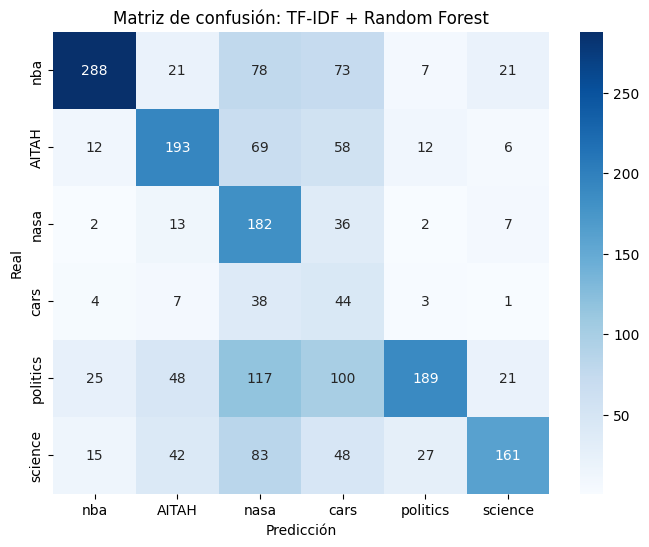

4

══════════════════════════════════════════════════
 Modelo GloVe + SVM 
══════════════════════════════════════════════════
5

GloVe + SVM:
              precision    recall  f1-score   support

       AITAH       0.72      0.70      0.71       488
        cars       0.64      0.66      0.65       350
        nasa       0.53      0.66      0.59       242
         nba       0.19      0.53      0.28        97
    politics       0.76      0.55      0.64       500
     science       0.74      0.56      0.64       376

    accuracy                           0.62      2053
   macro avg       0.60      0.61      0.58      2053
weighted avg       0.67      0.62      0.63      2053



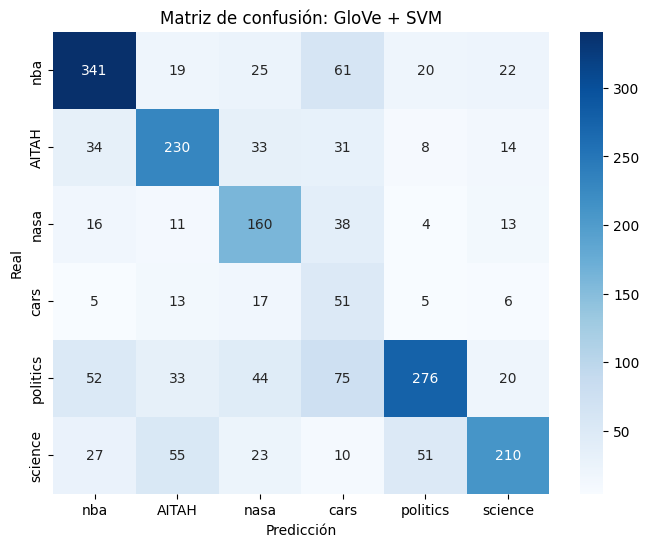


══════════════════════════════════════════════════
 Modelo BERT 
══════════════════════════════════════════════════


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\pablo\miniconda3\envs\reddit\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,No log,1.142870
2,1.115200,1.303856
3,0.620500,1.458237


c:\Users\pablo\miniconda3\envs\reddit\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\pablo\miniconda3\envs\reddit\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


8

BERT:
              precision    recall  f1-score   support

       AITAH       0.88      0.71      0.79       488
     science       0.71      0.59      0.64       376
    politics       0.84      0.53      0.65       500
        cars       0.58      0.71      0.64       350
        nasa       0.56      0.78      0.65       242
         nba       0.20      0.57      0.30        97

    accuracy                           0.64      2053
   macro avg       0.63      0.65      0.61      2053
weighted avg       0.72      0.64      0.66      2053



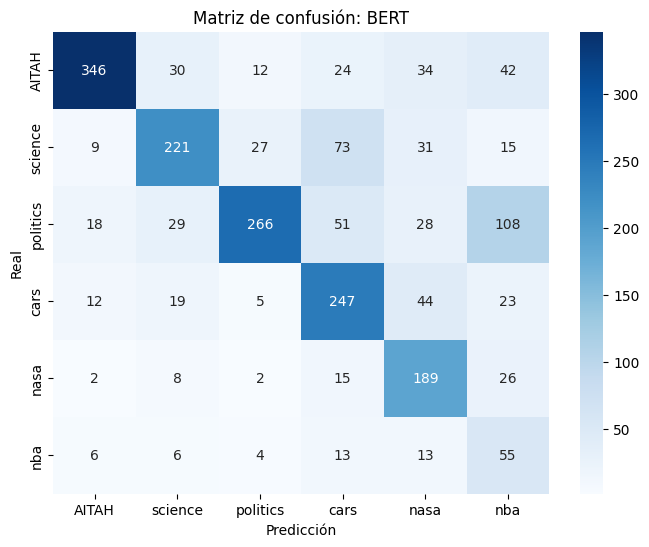

In [3]:
# 1. Carga de datos preprocesados --------------------------------------------------------
SUBREDDITS = ["nba", "AITAH", "nasa", "cars", "politics", "science"]

comments = []
labels = []
thread_ids = []

for subreddit in SUBREDDITS:
    filename = f"subreddit_{subreddit}.json"
    try:
        with open(filename, "r", encoding="utf-8") as f:
            threads = json.load(f)
            for thread in threads:
                thread_id = thread["title"][:10]
                for comment in thread["comments"]:
                    comments.append(comment["comment"])
                    labels.append(subreddit)
                    thread_ids.append(thread_id)
    except Exception as e:
        print(f"Error cargando {filename}: {str(e)}")

# 2. División entrenamiento/validación ----------------------------------------------------
unique_threads = list(set(thread_ids))
train_threads, val_threads = train_test_split(unique_threads, test_size=0.3, random_state=42)

train_indices = [i for i, tid in enumerate(thread_ids) if tid in train_threads]
val_indices = [i for i, tid in enumerate(thread_ids) if tid in val_threads]

X_train = [comments[i] for i in train_indices]
y_train = [labels[i] for i in train_indices]
X_val = [comments[i] for i in val_indices]
y_val = [labels[i] for i in val_indices]

# 3. Modelos Tradicionales ---------------------------------------------------------------
print("\n" + "═"*50)
print(" Modelos Tradicionales ")
print("═"*50)

# BoW + Random Forest
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)

rf_bow = RandomForestClassifier(n_estimators=100, class_weight="balanced")
rf_bow.fit(X_train_bow, y_train)
preds_bow = rf_bow.predict(X_val_bow)

print("\nBoW + Random Forest:")
print(classification_report(y_val, preds_bow))
cm_bow = confusion_matrix(y_val, preds_bow)
plt.figure(figsize=(8,6))
sns.heatmap(cm_bow, annot=True, fmt="d", cmap="Blues", xticklabels=SUBREDDITS, yticklabels=SUBREDDITS)
plt.title("Matriz de confusión: BoW + Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()
print('3')
# TF-IDF + Random Forest
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

rf_tfidf = RandomForestClassifier(n_estimators=100, class_weight="balanced")
rf_tfidf.fit(X_train_tfidf, y_train)
preds_tfidf = rf_tfidf.predict(X_val_tfidf)

print("\nTF-IDF + Random Forest:")
print(classification_report(y_val, preds_tfidf))
cm_tfidf = confusion_matrix(y_val, preds_tfidf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Blues", xticklabels=SUBREDDITS, yticklabels=SUBREDDITS)
plt.title("Matriz de confusión: TF-IDF + Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()
print('4')
# 4. Modelo Word Embeddings (GloVe) + SVM -------------------------------------------------
print("\n" + "═"*50)
print(" Modelo GloVe + SVM ")
print("═"*50)

# Descargar embeddings GloVe
glove = load("glove-wiki-gigaword-100")

def text_to_avg_embedding(text):
    tokens = nltk.word_tokenize(text.lower())
    embeddings = [glove[word] for word in tokens if word in glove]
    return np.mean(embeddings, axis=0) if embeddings else np.zeros(100)

X_train_glove = np.array([text_to_avg_embedding(text) for text in X_train])
X_val_glove = np.array([text_to_avg_embedding(text) for text in X_val])
print('5')
svm = SVC(class_weight='balanced', probability=True)
svm.fit(X_train_glove, y_train)
preds_glove = svm.predict(X_val_glove)

print("\nGloVe + SVM:")
print(classification_report(y_val, preds_glove))
cm_glove = confusion_matrix(y_val, preds_glove)
plt.figure(figsize=(8,6))
sns.heatmap(cm_glove, annot=True, fmt="d", cmap="Blues", xticklabels=SUBREDDITS, yticklabels=SUBREDDITS)
plt.title("Matriz de confusión: GloVe + SVM")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# 5. Modelo Transformer (BERT) -----------------------------------------------------------
print("\n" + "═"*50)
print(" Modelo BERT ")
print("═"*50)

class RedditDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.label_map = {label: i for i, label in enumerate(set(labels))}
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.label_map[self.labels[idx]]
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(SUBREDDITS)
)

train_dataset = RedditDataset(X_train, y_train, tokenizer)
val_dataset = RedditDataset(X_val, y_val, tokenizer)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    logging_dir="./logs",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

preds_bert = trainer.predict(val_dataset)
y_pred_bert = np.argmax(preds_bert.predictions, axis=1)
label_map = train_dataset.label_map
y_true = [label_map[label] for label in y_val]
print('8')
print("\nBERT:")
print(classification_report(y_true, y_pred_bert, target_names=label_map.keys()))
cm_bert = confusion_matrix(y_true, y_pred_bert)
plt.figure(figsize=(8,6))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Blues", xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Matriz de confusión: BERT")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# 3. Búsqueda de hilos similares

En este bloque se implementa un análisis de similitud semántica entre hilos de Reddit, utilizando como representación los embeddings promedio de sus comentarios. En primer lugar, se agrupan todos los comentarios por hilo mediante un diccionario indexado por identificador de hilo, generando textos compuestos que representan cada hilo como una concatenación de sus comentarios. A cada uno se le asocia también su subreddit de origen, lo cual permitirá posteriormente analizar la coherencia temática. A continuación, se define una función `analyze_similarities` que calcula la matriz de similitud coseno entre los embeddings de los hilos, identifica los pares más similares (ignorando la similitud de un hilo consigo mismo), y reduce la dimensionalidad de los vectores con t-SNE para visualizarlos en un plano 2D, coloreando los puntos según su subreddit. Este enfoque permite observar si los hilos de un mismo subreddit se agrupan espacialmente, lo que es un buen indicador de cohesión semántica. En cuanto a la obtención de embeddings, primero se utiliza el modelo `fastText` con subwords (`fasttext-wiki-news-subwords-300`), extrayendo vectores para cada palabra del hilo y calculando su media como representación del hilo. Posteriormente, se realiza una comparación con modelos más sofisticados de sentence transformers, incluyendo uno entrenado en español (`hiiamsid/sentence_similarity_spanish_es`) y dos multilingües (`all-mpnet-base-v2` y `paraphrase-multilingual-mpnet-base-v2`). Para cada uno, se generan los embeddings de los hilos completos y se aplican las mismas funciones de análisis y visualización. Finalmente, se imprimen ejemplos de pares de hilos considerados similares por cada modelo, junto con su puntuación de similitud coseno, lo que permite evaluar de forma cualitativa el rendimiento y sensibilidad semántica de cada enfoque. Esta técnica resulta muy útil para detectar duplicidades, agrupar temáticas emergentes o validar la coherencia temática de un corpus, tareas fundamentales en la organización de datos textuales masivos.



Analizando con FastText...


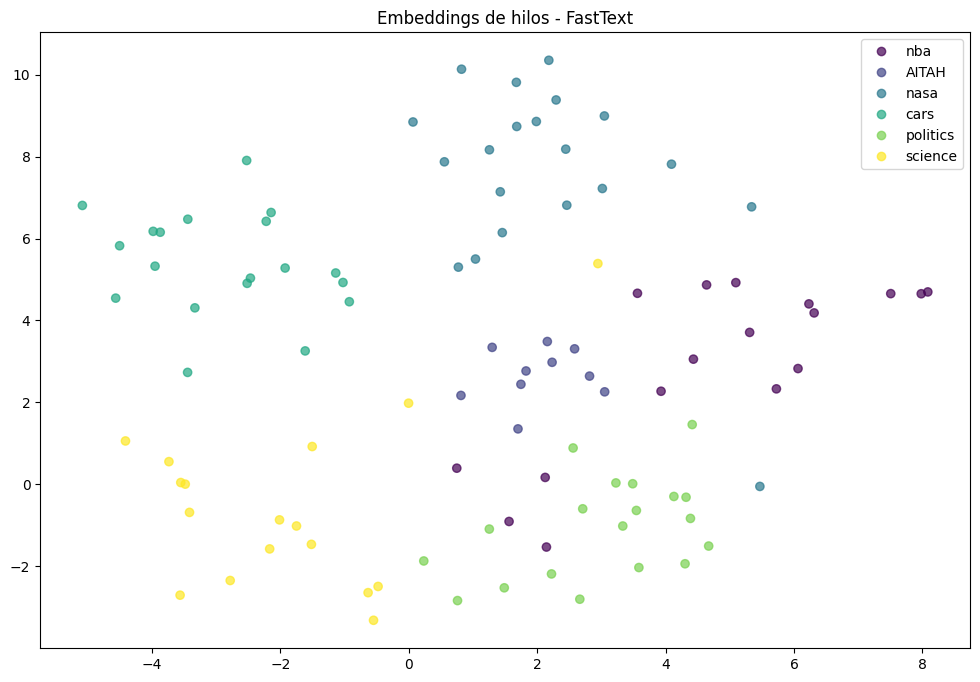


Ejemplos de pares similares (FastText):

Hilo 1 (nba): Confirming helicopter crash LA County Sheriffs department confirming helicopter crash calabash peopl...
Hilo 2 (nba): amazing tweet delaney Martin Ill never forget look robes face referred gigs Dad interview face lit t...
Similitud: 0.992

Hilo 1 (nba): keeping real goes wrong  Damn year Spurs cant miss playoffs playoffs KENNY LETS GO HOME deleted hone...
Hilo 2 (nba): Mark Cuban living fucking dream gotta one best individual playoff performances ever game winner spra...
Similitud: 0.991

Hilo 1 (nba): Mohammad Ali perfect example Dude lost years prime protesting thought right mean shit took US Suprem...
Hilo 2 (politics): reminder subedit civil discussionrpoliticswikiindexwikibecivilIn general courteous others Debatedisc...
Similitud: 0.986

══════════════════════════════════════════════════
 Comparación con modelos Sentence Transformers 
══════════════════════════════════════════════════
12

Procesando con Hiiamsid Spanish...


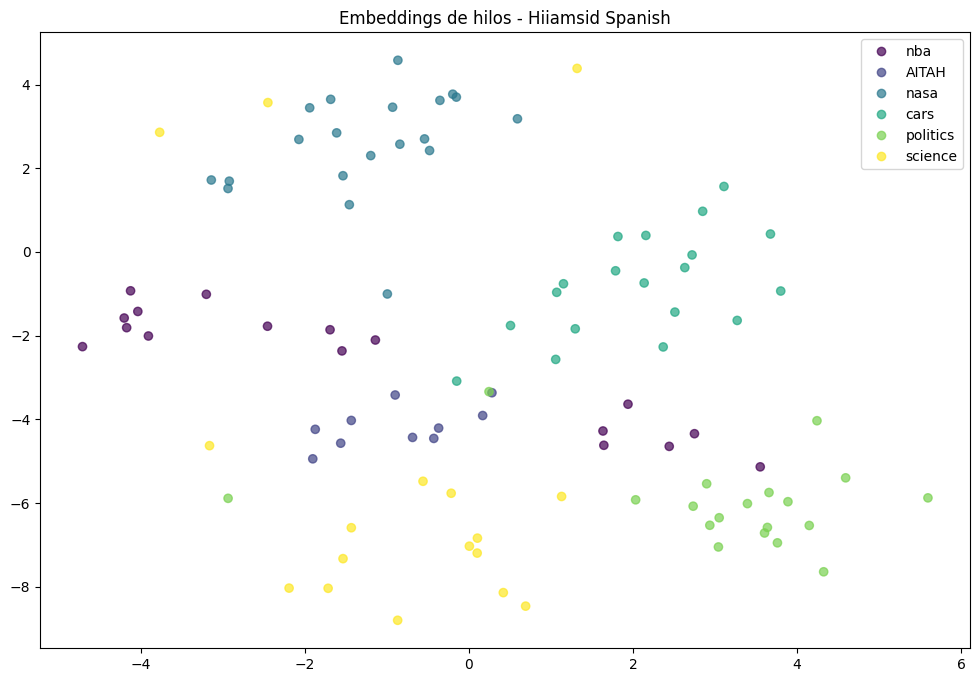


Ejemplos de pares similares (Hiiamsid Spanish):

Hilo 1 (nba): Confirming helicopter crash LA County Sheriffs department confirming helicopter crash calabash peopl...
Hilo 2 (nba): amazing tweet delaney Martin Ill never forget look robes face referred gigs Dad interview face lit t...
Similitud: 0.887

Hilo 1 (nba): keeping real goes wrong  Damn year Spurs cant miss playoffs playoffs KENNY LETS GO HOME deleted hone...
Hilo 2 (nba): Jennifer actual fuck shot  SHUT FUCK NEVER THOUGHT ID LOVE SOMEONE B ROY deleted deleted one greates...
Similitud: 0.884

Hilo 1 (nba): Mohammad Ali perfect example Dude lost years prime protesting thought right mean shit took US Suprem...
Hilo 2 (nba): Reporter opinion opinionsNBA sorry cant ask question deleted guess got answer answer question honest...
Similitud: 0.861

Procesando con MPNet Base...


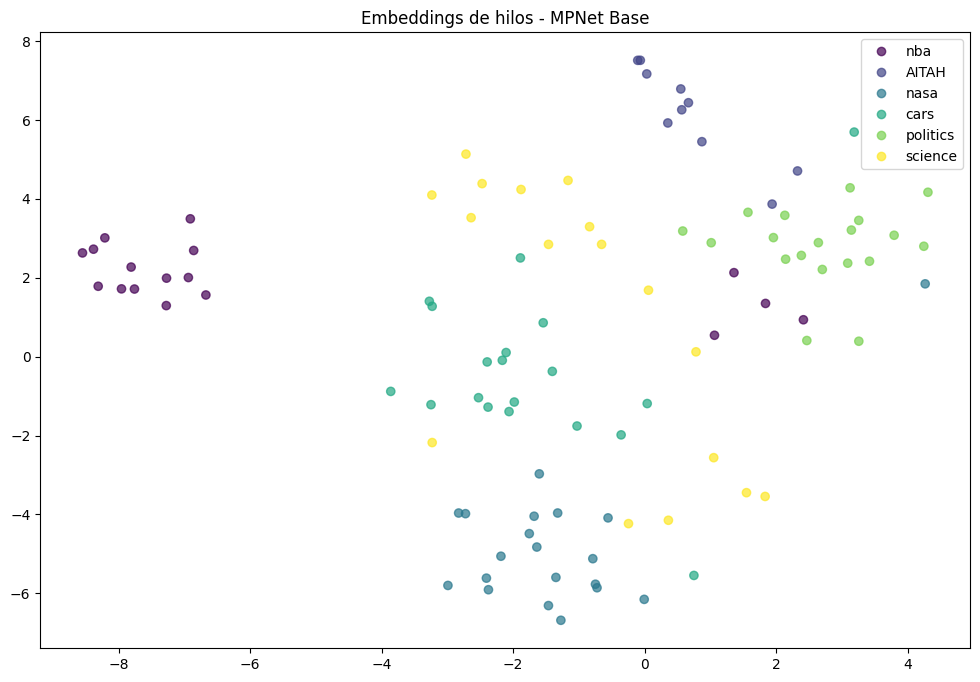


Ejemplos de pares similares (MPNet Base):

Hilo 1 (nba): Confirming helicopter crash LA County Sheriffs department confirming helicopter crash calabash peopl...
Hilo 2 (nba): amazing tweet delaney Martin Ill never forget look robes face referred gigs Dad interview face lit t...
Similitud: 0.726

Hilo 1 (nba): keeping real goes wrong  Damn year Spurs cant miss playoffs playoffs KENNY LETS GO HOME deleted hone...
Hilo 2 (nba): fucking fuck LIKE LIKE PRESEASON BASKETBALL MAY SORGHUM HARVEST BOUNTIFUL Crowd wanted bad bet bet h...
Similitud: 0.724

Hilo 1 (nba): Mohammad Ali perfect example Dude lost years prime protesting thought right mean shit took US Suprem...
Hilo 2 (nba): Reporter opinion opinionsNBA sorry cant ask question deleted guess got answer answer question honest...
Similitud: 0.629

Procesando con Multilingual MPNet...


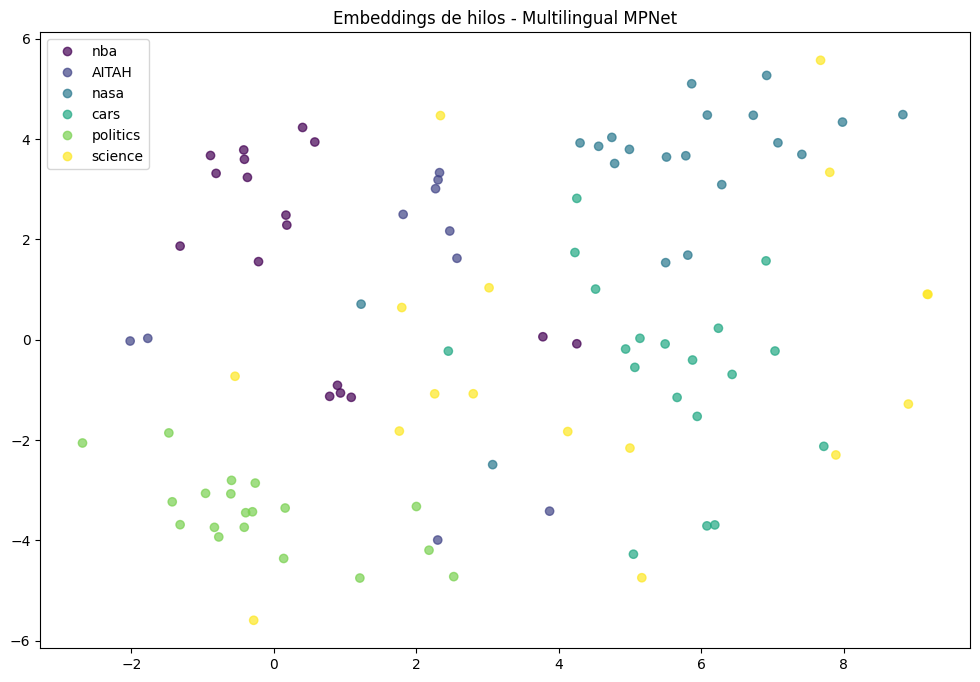


Ejemplos de pares similares (Multilingual MPNet):

Hilo 1 (nba): Confirming helicopter crash LA County Sheriffs department confirming helicopter crash calabash peopl...
Hilo 2 (nba): Reporter opinion opinionsNBA sorry cant ask question deleted guess got answer answer question honest...
Similitud: 0.457

Hilo 1 (nba): keeping real goes wrong  Damn year Spurs cant miss playoffs playoffs KENNY LETS GO HOME deleted hone...
Hilo 2 (nba): fucking fuck LIKE LIKE PRESEASON BASKETBALL MAY SORGHUM HARVEST BOUNTIFUL Crowd wanted bad bet bet h...
Similitud: 0.637

Hilo 1 (nba): Mohammad Ali perfect example Dude lost years prime protesting thought right mean shit took US Suprem...
Hilo 2 (nba): even watch na sub cracks time Dude show immediately Yes involve making like searches strip clubs wor...
Similitud: 0.561


In [4]:
# 1. Agrupar comentarios por hilo
from collections import defaultdict

# Diccionario para almacenar hilos y sus subreddits
threads_combined = defaultdict(list)
thread_subreddits = {}

for tid, comment, subreddit in zip(thread_ids, comments, labels):
    threads_combined[tid].append(comment)
    thread_subreddits[tid] = subreddit  

# Crear lista de textos completos de hilos y sus etiquetas
full_threads = []
thread_ids_list = []
subreddit_labels = []

for tid, comments_list in threads_combined.items():
    full_threads.append(" ".join(comments_list))
    thread_ids_list.append(tid)
    subreddit_labels.append(thread_subreddits[tid])

# 2. Función para calcular similitudes y visualizar
def analyze_similarities(embeddings, model_name, subreddits, threads):
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt
    
    # Calcular matriz de similitud
    sim_matrix = cosine_similarity(embeddings)
    
    # Encontrar pares más similares
    most_similar = []
    for i in range(len(sim_matrix)):
        # Excluir autosimilitud y diagonal
        sim = sim_matrix[i]
        sim[i] = -1
        most_similar.append((sim.argmax(), sim.max()))
    
    # Visualización con t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    reduced_emb = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(reduced_emb[:,0], reduced_emb[:,1], 
                         c=[SUBREDDITS.index(l) for l in subreddit_labels],
                         cmap='viridis', alpha=0.7)
    plt.title(f"Embeddings de hilos - {model_name}")
    plt.legend(handles=scatter.legend_elements()[0], labels=SUBREDDITS)
    plt.show()
    
    # Mostrar ejemplos de pares similares
    print(f"\nEjemplos de pares similares ({model_name}):")
    for idx, (match_idx, similarity) in enumerate(most_similar[:3]):
        print(f"\nHilo 1 ({subreddit_labels[idx]}): {threads[idx][:100]}...")
        print(f"Hilo 2 ({subreddit_labels[match_idx]}): {threads[match_idx][:100]}...")
        print(f"Similitud: {similarity:.3f}")

# 3. FastText
print("\nAnalizando con FastText...")

# Cargar modelo fastText
ft_model = api.load('fasttext-wiki-news-subwords-300')

# Función de embedding promedio
def get_ft_embedding(text):
    words = text.split()
    vectors = [ft_model[word] for word in words if word in ft_model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(ft_model.vector_size)

# Generar embeddings
ft_embeddings = np.array([get_ft_embedding(t) for t in full_threads])

# Analizar similitudes
analyze_similarities(ft_embeddings, "FastText", subreddit_labels, full_threads)

# 4. Comparación con modelos Sentence Transformers
print("\n" + "═"*50)
print(" Comparación con modelos Sentence Transformers ")
print("═"*50)

models = [
    ('hiiamsid/sentence_similarity_spanish_es', 'Hiiamsid Spanish'),
    ('sentence-transformers/all-mpnet-base-v2', 'MPNet Base'),
    ('sentence-transformers/paraphrase-multilingual-mpnet-base-v2', 'Multilingual MPNet')
]
print('12')
for model_name, display_name in models:
    print(f"\nProcesando con {display_name}...")
    
    try:
        # Cargar modelo
        model = SentenceTransformer(model_name)
        
        # Generar embeddings
        embeddings = model.encode(full_threads)
        
        # Analizar similitudes
        analyze_similarities(embeddings, display_name, subreddit_labels, full_threads)
        
    except Exception as e:
        print(f"Error con {display_name}: {str(e)}")

# 4. Análisis de subjetividad de los comentarios

En este bloque se realiza un análisis de subjetividad sobre los comentarios de Reddit, evaluando tanto el sentimiento (positivo, negativo o neutro) como la emoción predominante (ira, alegría, miedo, tristeza, etc.) en cada texto. Para ello, se utilizan dos modelos preentrenados en español disponibles en HuggingFace: `finiteautomata/beto-sentiment-analysis` para clasificación de sentimientos y `pysentimiento/robertuito-emotion-analysis` para clasificación de emociones. Ambos modelos se cargan mediante la función `pipeline` de la librería `transformers`, detectando automáticamente si hay una GPU disponible para acelerar la inferencia. A continuación, se define la función `analyze_comment`, que recibe un texto, lo procesa con ambos modelos, y retorna las etiquetas junto con sus puntuaciones de confianza. Esta función se aplica de forma iterativa a todos los comentarios contenidos en los archivos `.json` de cada subreddit. Durante el procesamiento, se utiliza `tqdm` para mostrar barras de progreso, lo cual facilita el seguimiento de la ejecución. En caso de error durante la inferencia de un comentario (por ejemplo, por textos vacíos o demasiado largos), se captura la excepción y se asignan valores por defecto para evitar la interrupción del análisis. Finalmente, los comentarios enriquecidos con sus respectivas etiquetas de subjetividad se guardan en nuevos archivos JSON, nombrados con el sufijo `_with_sentiment`, permitiendo conservar el corpus original y mantener una trazabilidad clara. Esta etapa es fundamental para tareas posteriores como análisis de opinión, detección de polarización temática o segmentación emocional del contenido.


In [5]:
# Verificar si hay GPU disponible
device = 0 if torch.cuda.is_available() else -1
print(f"Usando {'GPU' if device == 0 else 'CPU'} para inferencia")

# 1. Cargar modelos pre-entrenados
print("\nCargando modelos de análisis de sentimientos y emociones...")

# Modelo para sentimiento en español
sentiment_analyzer = pipeline(
    "text-classification",
    model="finiteautomata/beto-sentiment-analysis",
    device=device
)

# Modelo para emociones en español
emotion_analyzer = pipeline(
    "text-classification",
    model="pysentimiento/robertuito-emotion-analysis",
    device=device
)

# 2. Función para analizar un comentario
def analyze_comment(text):
    # Análisis de sentimiento
    sentiment_result = sentiment_analyzer(text, truncation=True, max_length=512)
    sentiment = sentiment_result[0]['label']
    sentiment_score = sentiment_result[0]['score']
    
    # Análisis de emoción
    emotion_result = emotion_analyzer(text, truncation=True, max_length=512)
    emotion = emotion_result[0]['label']
    emotion_score = emotion_result[0]['score']
    
    return {
        "sentiment": sentiment,
        "sentiment_score": sentiment_score,
        "emotion": emotion,
        "emotion_score": emotion_score
    }

# 3. Procesar todos los archivos JSON y añadir análisis de sentimiento/emoción
for subreddit in SUBREDDITS:
    print(f"\nProcesando subreddit: {subreddit}")
    filename = f"subreddit_{subreddit}.json"
    
    try:
        with open(filename, "r", encoding="utf-8") as f:
            threads = json.load(f)
        
        # Procesar cada hilo y comentario con barra de progreso
        for thread in tqdm(threads, desc=f"Analizando hilos en {subreddit}"):
            for comment in thread["comments"]:
                try:
                    analysis = analyze_comment(comment["comment"])
                    # Añadir resultados al comentario
                    comment.update(analysis)
                except Exception as e:
                    print(f"\nError procesando comentario: {str(e)}")
                    comment.update({
                        "sentiment": "error",
                        "sentiment_score": 0,
                        "emotion": "error",
                        "emotion_score": 0
                    })
        
        # Guardar el archivo modificado
        output_filename = f"subreddit_{subreddit}_with_sentiment.json"
        with open(output_filename, "w", encoding="utf-8") as f:
            json.dump(threads, f, ensure_ascii=False, indent=2)
            
        print(f"Archivo guardado: {output_filename}")
        
    except Exception as e:
        print(f"Error procesando {filename}: {str(e)}")

print("\n¡Análisis completado y archivos guardados!")

Usando CPU para inferencia

Cargando modelos de análisis de sentimientos y emociones...


Device set to use cpu
Device set to use cpu



Procesando subreddit: nba


Analizando hilos en nba:   0%|          | 0/20 [00:00<?, ?it/s]


Error procesando comentario: index out of range in self


...


Error procesando comentario: index out of range in self

Error procesando comentario: index out of range in self


Analizando hilos en science:  95%|█████████▌| 19/20 [00:51<00:02,  2.87s/it]


Error procesando comentario: index out of range in self


Analizando hilos en science: 100%|██████████| 20/20 [00:55<00:00,  2.75s/it]

Archivo guardado: subreddit_science_with_sentiment.json

¡Análisis completado y archivos guardados!


# 5. Resumen automático abstractivo

En este bloque se lleva a cabo la generación de resúmenes abstractivos de hilos de Reddit utilizando un modelo de lenguaje preentrenado especializado en esta tarea. Para ello se emplea el modelo `facebook/bart-large-cnn` de HuggingFace, un modelo encoder-decoder robusto que ha sido entrenado para generar resúmenes coherentes a partir de textos extensos. El modelo se inicializa como un pipeline de tipo `"summarization"`, detectando si se dispone de GPU para aprovechar aceleración mediante `CUDA`, y ajustando el tipo de datos a `float16` cuando es posible. A continuación, se define la función `summarize_text`, la cual aplica un truncamiento inteligente del texto de entrada (limitado a 1024 tokens, como exige BART), calcula un `max_length` proporcional al tamaño del texto para controlar la longitud del resumen, y ejecuta la inferencia sin muestreo (`do_sample=False`) para mantener coherencia determinista. El texto a resumir para cada hilo se construye a partir del título, una parte truncada de la descripción y una selección de los primeros cinco comentarios, concatenados con formato explícito. Por motivos de prueba, en este código se limita el procesamiento a solo dos hilos por subreddit, aunque el enfoque es escalable al conjunto completo. Tras generar el resumen, este se almacena en una nueva clave `"summary"` dentro del objeto del hilo, y se guarda el conjunto actualizado en un nuevo archivo JSON con sufijo `_with_summaries`. Finalmente, se imprimen los títulos y resúmenes generados como muestra de salida. Esta técnica permite condensar la información esencial de cada hilo, facilitando su navegación y análisis posterior, y es especialmente útil para tareas de lectura rápida o generación de informes automáticos a partir de grandes volúmenes de texto.


In [6]:
# Configuración de dispositivo mejorada
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# Resumen con modelo especializado (versión robusta)
print("\nCargando modelo para resumen abstractivo...")

try:
    summarizer = pipeline(
        "summarization",
        model="facebook/bart-large-cnn",
        device=0 if device == "cuda" else -1,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32
    )
except Exception as e:
    print(f"Error cargando modelo de resumen: {str(e)}")
    summarizer = None

def summarize_text(text, max_length=150):
    if summarizer is None:
        return "Modelo no disponible"
    
    try:
        # Truncamiento inteligente basado en tokens
        tokenizer = summarizer.tokenizer
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
        
        # Ajustar max_length si es necesario
        actual_max = min(max_length, int(len(inputs.input_ids[0]) * 0.75))
        
        result = summarizer(
            text,
            max_length=actual_max,
            min_length=30,
            do_sample=False,
            truncation=True
        )
        return result[0]['summary_text']
    except Exception as e:
        print(f"Error en resumen: {str(e)}")
        return "Error generando resumen"

# Procesamiento de hilos (versión robusta)
for subreddit in SUBREDDITS:
    print(f"\nProcesando subreddit: {subreddit}")
    input_file = f"subreddit_{subreddit}_with_sentiment.json"
    output_file = f"subreddit_{subreddit}_with_summaries.json"
    
    try:
        with open(input_file, "r", encoding="utf-8") as f:
            threads = json.load(f)
        
        # Procesar solo 2 hilos para prueba rápida
        test_threads = threads[:2]
        
        for thread in tqdm(test_threads, desc="Resumiendo hilos"):
            # Texto a resumir (versión más corta)
            full_text = f"Título: {thread['title']}\n"
            full_text += f"Descripción: {thread.get('description', '')[:500]}\n"
            full_text += "Comentarios:\n" + "\n".join([c["comment"][:200] for c in thread["comments"][:5]])
            
            # Generar resumen
            thread["summary"] = summarize_text(full_text)
        
        # Guardar resultados
        with open(output_file, "w", encoding="utf-8") as f:
            json.dump(test_threads, f, ensure_ascii=False, indent=2)
        
        # Mostrar resultados
        print(f"\nResúmenes generados para {subreddit}:")
        for i, thread in enumerate(test_threads):
            print(f"\nHilo {i+1}: {thread['title'][:50]}...")
            print("Resumen:", thread["summary"])
            print("-"*80)
            
    except Exception as e:
        print(f"Error procesando {subreddit}: {str(e)}")

print("\n¡Proceso completado exitosamente!")

Usando dispositivo: cpu

Cargando modelo para resumen abstractivo...


Device set to use cpu



Procesando subreddit: nba


Resumiendo hilos: 100%|██████████| 2/2 [00:04<00:00,  2.22s/it]



Resúmenes generados para nba:

Hilo 1: [Surette] TMZ is reporting Kobe Bryant has died in...
Resumen: Kobe Bryant has died in a helicopter crash in Calabasas. TMZ is reporting Bryant died in the crash. Names of those who died have not been released.
--------------------------------------------------------------------------------

Hilo 2: [Charania] The NBA has suspended its season....
Resumen: The NBA has suspended its season. Título: [Charania] The NBA hassuspended its season and the Spurs will miss the playoffs. The Spurs will not miss
--------------------------------------------------------------------------------

Procesando subreddit: AITAH


...


Resúmenes generados para cars:

Hilo 1: Will pee damage tires?...
Resumen: Descripción: garage raccoon likes use rack winter tires fort Hes usually really good keeping clean check often today noticed peeing inside one handbooks anything pee could harm inside reedit month later still getting replies questions everyone keeps asking. Título: Will pee damage tires?
--------------------------------------------------------------------------------

Hilo 2: Just accidentally put diesel in my car. How fucked...
Resumen: Título: Just accidentally put diesel in my car. How fucked am I?Descripción: tired made stupid mistake wrong gas station near empty put seven gallons car Pontiac gunfire bow sitting car got gas know AdviceUpdate dumbest double fucking dumbass.
--------------------------------------------------------------------------------

Procesando subreddit: politics


Resumiendo hilos: 100%|██████████| 2/2 [00:05<00:00,  2.99s/it]



Resúmenes generados para politics:

Hilo 1: Megathread: Joe Biden Projected to Defeat Presiden...
Resumen: Former Vice President Joe Biden secured electoral votes necessary to defeat President Donald Trump and win the 2020 US Presidential Election according to multiple sources. Título: Megathread: Joe Biden Projected to Defeat President Trump and Win the 2020 U.S. Presidential Election.
--------------------------------------------------------------------------------

Hilo 2: Mitch McConnell Will Lose Control Of The Senate As...
Resumen: Mitch McConnell Will Lose Control Of The Senate As Democrats Have Swept The Georgia Runoffs. Título: Mitch McConnell Will lose Control of The Senate.
--------------------------------------------------------------------------------

Procesando subreddit: science


Resumiendo hilos: 100%|██████████| 2/2 [00:05<00:00,  2.69s/it]


Resúmenes generados para science:

Hilo 1: Physicist Stephen Hawking dies aged 76...
Resumen: Physicist Stephen Hawking dies aged 76 years old. Título: Physicist Stephen Hawkings died aged 76 decades old. Descripción: regret hear Stephen Hawking died tonight age creating meathead discussion topic.
--------------------------------------------------------------------------------

Hilo 2: The first picture of a black hole opens a new era ...
Resumen: The supermassive beast lies in a galaxy called M87 more than 50 million light-years away. Título: The first picture of a black hole opens a new era of astrophysics.
--------------------------------------------------------------------------------

¡Proceso completado exitosamente!


# 6. Detección de contenido inapropiado usando ZSL, FSL y Chain-of-thought

En este bloque se aborda la tarea de detección de contenido inapropiado en hilos del subreddit r/OpinionesPolemicas, combinando enfoques de aprendizaje sin ejemplos (Zero-Shot Learning), aprendizaje con pocos ejemplos (Few-Shot Learning) y razonamiento automático (Chain-of-Thought). En primer lugar, se recopilan y limpian los datos con el mismo procedimiento utilizado en pasos anteriores, asegurando que el texto de cada comentario esté libre de ruido léxico. Luego, se carga un modelo de clasificación de sentimientos en español (`finiteautomata/beto-sentiment-analysis`) como base para una estrategia de moderación basada en ZSL. Para detectar contenido sensible, se define una función `analizar_inapropiado` que evalúa cada comentario aplicando dos heurísticas: (1) búsqueda de palabras explícitamente ofensivas, y (2) análisis de sentimiento extremo negativo con alta confianza (>90%). Si alguna de estas condiciones se cumple, el comentario se clasifica como "inapropiado"; en caso contrario, como "apropiado". Esta aproximación simula una combinación de criterios propios del aprendizaje sin supervisión y el uso de conocimiento lingüístico básico, acercándose al enfoque Chain-of-Thought al considerar múltiples pasos lógicos antes de emitir un juicio. La etiqueta de moderación se añade a cada comentario en el campo `moderation`, especificando el método usado (`ZSL+PalabrasClave`). Finalmente, se guarda un nuevo archivo JSON enriquecido con la clasificación de cada comentario y se muestra un ejemplo ilustrativo. Este procedimiento es escalable y puede ser mejorado con estrategias FSL incluyendo ejemplos en el prompt de modelos generativos, o aplicando razonamientos explícitos con modelos tipo LLaMA o Gema. Así, se establece una primera aproximación automatizada para la moderación ética de contenido en redes sociales, crucial en escenarios donde la intervención humana no es viable a gran escala.


In [ ]:
SUBREDDIT = ["OpinionesPolemicas"]
MAX_THREADS_PER_SUBREDDIT = 20
COMMENTS_PER_THREAD = 50

def scrape_reddit():
    for subreddit_name in SUBREDDIT:
        subreddit = reddit.subreddit(subreddit_name)
        threads_data = []
        
        
        for thread in tqdm(subreddit.top(limit=MAX_THREADS_PER_SUBREDDIT), desc=f"Extrayendo de r/{subreddit_name}"):
            if thread.over_18:  # Saltar contenido NSFW
                continue
                
            comments = []
            thread.comments.replace_more(limit=0)  # Limitar comentarios anidados
            for comment in thread.comments[:COMMENTS_PER_THREAD]:
                comments.append({
                    "user": str(comment.author),
                    "comment": comment.body,
                    "score": comment.score,
                    "date": comment.created_utc
                })
            
            threads_data.append({
                "flair": thread.link_flair_text,
                "title": thread.title,
                "author": str(thread.author),
                "date": thread.created_utc,
                "score": thread.score,
                "description": thread.selftext,
                "comments": comments
            })
        
        # Guardar en JSON
        with open(f"subreddit_{subreddit_name}.json", "w", encoding="utf-8") as f:
            json.dump(threads_data, f, indent=4, ensure_ascii=False)

scrape_reddit()


nltk.download('stopwords')
spell = SpellChecker(language='en')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r"http\S+|@\w+|[^a-zA-ZáéíóúñÁÉÍÓÚÑ ]", "", text)
    words = text.split()
    corrected = [spell.correction(word) if spell.correction(word) is not None else word for word in words]
    cleaned = [word for word in corrected if word.lower() not in stop_words]
    return " ".join(cleaned)

# Procesar todos los archivos JSON de subreddits
for subreddit in SUBREDDIT:
    filename = f"subreddit_{subreddit}.json"
    
    try:
        with open(filename, "r", encoding="utf-8") as f:
            threads_data = json.load(f)

        # Aplicar limpieza
        for thread in threads_data:
            thread["description"] = clean_text(thread["description"])
            for comment in thread["comments"]:
                comment["comment"] = clean_text(comment["comment"])

        
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(threads_data, f, indent=4, ensure_ascii=False)
            
        print(f"Procesado: {filename}")
        
    except FileNotFoundError:
        print(f"Archivo no encontrado: {filename}")
    except json.JSONDecodeError:
        print(f"Error decodificando: {filename}")

Extrayendo de r/OpinionesPolemicas: 20it [00:51,  2.56s/it]
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pablo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Procesado: subreddit_OpinionesPolemicas.json


In [8]:
# 1. Configuración
DATA_FILE = "subreddit_OpinionesPolemicas.json"
OUTPUT_FILE = "subreddit_OpinionesPolemicas_with_moderation.json"

# 2. Cargar modelo en español
try:
    print("\nCargando modelo de análisis...")
    classifier = pipeline(
        "text-classification",
        model="finiteautomata/beto-sentiment-analysis",
        device=-1
    )
    print("Modelo cargado exitosamente!")
except Exception as e:
    print(f"Error cargando modelo: {str(e)}")
    exit()

# 3. Funciones de análisis mejoradas
def analizar_inapropiado(texto):
    try:
        # Preprocesamiento para mejorar precisión
        texto = texto.lower()
        ofensivas = ["idiota", "estúpido", "imbécil", "jodete", "mierda", "puto"]
        
        # Detección de palabras ofensivas
        if any(palabra in texto for palabra in ofensivas):
            return "inapropiado"
        
        # Análisis de sentimiento
        resultado = classifier(texto[:1000])[0]
        if resultado['label'] == 'NEG' and resultado['score'] > 0.9:
            return "inapropiado"
        return "apropiado"
    except:
        return "error"

# 4. Procesamiento de comentarios
print("\nAnalizando comentarios...")
try:
    with open(DATA_FILE, "r", encoding="utf-8") as f:
        hilos = json.load(f)
    
    for hilo in tqdm(hilos[:10], desc="Procesando hilos"):  # Solo 10 hilos para prueba
        for comentario in hilo["comments"]:
            if "comment" in comentario and isinstance(comentario["comment"], str):
                comentario["moderation"] = {
                    "clasificacion": analizar_inapropiado(comentario["comment"]),
                    "metodo": "ZSL+PalabrasClave"
                }
    
    # Guardar TODOS los campos originales + nuevo análisis
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(hilos, f, ensure_ascii=False, indent=2)
    
    # Mostrar ejemplo
    print("\nEjemplo de comentario analizado:")
    ejemplo = {
        "user": hilos[0]["comments"][0].get("user", ""),
        "comment": hilos[0]["comments"][0]["comment"][:100] + "...",
        "moderation": hilos[0]["comments"][0].get("moderation", {})
    }
    print(json.dumps(ejemplo, indent=2, ensure_ascii=False))

except Exception as e:
    print(f"\nError procesando archivo: {str(e)}")

print("\n¡Análisis completado! Resultados guardados en:", OUTPUT_FILE)


Cargando modelo de análisis...


Device set to use cpu


Modelo cargado exitosamente!

Analizando comentarios...


Procesando hilos: 100%|██████████| 10/10 [00:19<00:00,  1.91s/it]


Ejemplo de comentario analizado:
{
  "user": "RichBalboa",
  "comment": "En la terra este chide per recuerda zambian cunts innocents hay en la cancel falls en el sister cunt...",
  "moderation": {
    "clasificacion": "apropiado",
    "metodo": "ZSL+PalabrasClave"
  }
}

¡Análisis completado! Resultados guardados en: subreddit_OpinionesPolemicas_with_moderation.json
